# Exploratory Data Analysis

## Import dan Konfigurasi Library

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_rows", 60)

## 1. Exploratory Data Analysis pada Data Mentah

EDA pertama yang dilakukan merupakan EDA terhadap data mentah, yaitu sebelum dilakukannya drop kolom shortcut (ICULOS, Hour, HospAdmTim) maupun imputasi. 

In [3]:
df = pd.read_csv("../data/Dataset.csv", index_col=0)
print("Shape:", df.shape)
df.head()

Shape: (1552210, 43)


,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0,17072
1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0,17072
2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0,17072
3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0,17072
4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,NaN,...,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0,17072


### 1.1 Analisis Missing Value (Sparsity)

In [4]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_table = missing_pct.to_frame("missing_pct").round(2)
print("Missing % per kolom (desc):")
print(missing_table.to_string())

focus = ["Lactate", "O2Sat", "pH", "PaCO2", "SaO2", "Resp"]
print("\nFocus clinical markers (missing %):")
print(missing_pct.loc[focus].round(2).to_string())

Missing % per kolom (desc):
                  missing_pct
Bilirubin_direct        99.81
Fibrinogen              99.34
TroponinI               99.05
Bilirubin_total         98.51
Alkalinephos            98.39
AST                     98.38
Lactate                 97.33
PTT                     97.06
SaO2                    96.55
EtCO2                   96.29
Phosphate               95.99
HCO3                    95.81
Chloride                95.46
BaseExcess              94.58
PaCO2                   94.44
Calcium                 94.12
Platelets               94.06
Creatinine              93.90
Magnesium               93.69
WBC                     93.59
BUN                     93.13
pH                      93.07
Hgb                     92.62
FiO2                    91.67
Hct                     91.15
Potassium               90.69
Glucose                 82.89
Temp                    66.16
Unit1                   39.43
Unit2                   39.43
DBP                     31.35
Resp        

### 1.2 Asosiasi Fitur dengan Target Pearson r

Data null (NaN) diisi dengan median sebagai nilai sementara hanya untuk perhitungan korelasi (tidak di-persist ke dataframe utama).

Top 15 Pearson r vs SepsisLabel:
ICULOS             0.1338
Hour               0.1338
HR                 0.0472
Resp               0.0430
Temp               0.0280
Patient_ID         0.0279
HospAdmTime        0.0191
BUN                0.0189
MAP                0.0172
Calcium            0.0156
DBP                0.0145
Lactate            0.0132
SBP                0.0124
WBC                0.0122
Bilirubin_total    0.0119


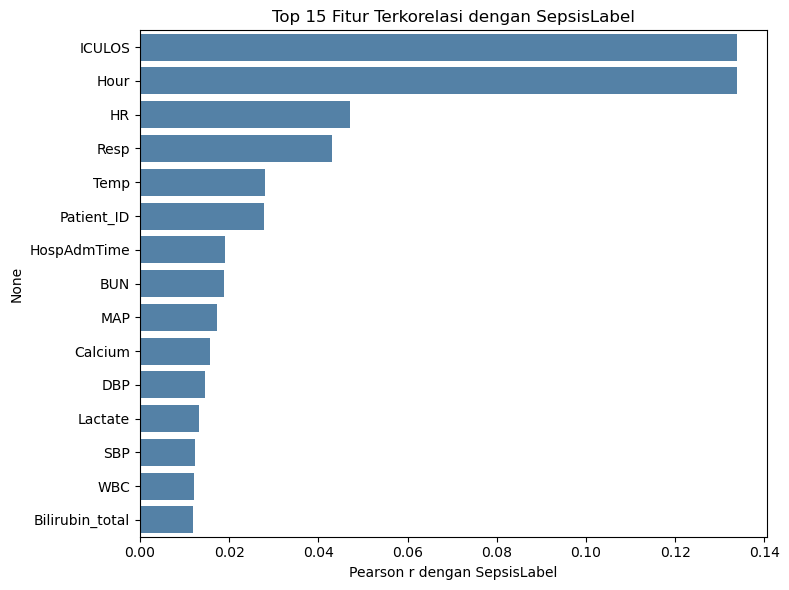

In [5]:
num = df.select_dtypes(include=[np.number]).copy()
num_filled = num.fillna(num.median(numeric_only=True))
corr = num_filled.corr(method="pearson")["SepsisLabel"].drop("SepsisLabel").abs()
top15 = corr.sort_values(ascending=False).head(15)
print("Top 15 Pearson r vs SepsisLabel:")
print(top15.round(4).to_string())

plt.figure(figsize=(8, 6))
sns.barplot(x=top15.values, y=top15.index, orient="h", color="steelblue")
plt.xlabel("Pearson r dengan SepsisLabel")
plt.title("Top 15 Fitur Terkorelasi dengan SepsisLabel")
plt.tight_layout()
plt.savefig("../reports/eda_feature_correlation.png", dpi=150)
plt.show()

### 1.3 Distribusi Kelas Target

In [6]:
counts = df["SepsisLabel"].value_counts().sort_index()
pcts = (df["SepsisLabel"].value_counts(normalize=True).sort_index() * 100).round(3)
summary = pd.DataFrame({"count": counts, "pct": pcts})
print(summary)
print(f"\nImbalance ratio (neg:pos) = {counts.loc[0] / counts.loc[1]:.1f} : 1")

               count     pct
SepsisLabel                 
0            1524294  98.202
1              27916   1.798

Imbalance ratio (neg:pos) = 54.6 : 1


## 2.Balanced Resampling dan Secondary EDA

Langkah EDA ini terdiri dari pipeline preprocessing terkontrol untuk mencegah model mengambil shortcut administratif (ICULOS, Hour, HospAdmTime, Patient_ID) dan memastikan marker biologis (Lactate, O2Sat, dll.) mendominasi sinyal.

Langkah yang dilakukan untuk bagian ini antara lain:
1. Imputasi per pasien: groupby(Patient_ID).ffill() lalu fill sisa NaN dengan median global.
2. Downsampling kelas mayoritas: rasio 1:2 (negatif:positif) dengan random_state=42.
3. Secondary EDA: hitung ulang Pearson r pada dataset balanced.

### 2.1 Imputasi Timeline per-Pasien (ffill dan median)

In [7]:
df_raw = pd.read_csv("../data/Dataset.csv", index_col=0)
df_raw = df_raw.sort_values(["Patient_ID", "Hour"]).reset_index(drop=True)
print("Raw shape:", df_raw.shape)
print("NaN total sebelum imputasi:", int(df_raw.isna().sum().sum()))

clinical_cols = [c for c in df_raw.columns if c not in ("Patient_ID", "SepsisLabel")]

df_imp = df_raw.copy()
df_imp[clinical_cols] = df_imp.groupby("Patient_ID")[clinical_cols].ffill()

global_medians = df_imp[clinical_cols].median(numeric_only=True)
df_imp[clinical_cols] = df_imp[clinical_cols].fillna(global_medians)

print("NaN total setelah ffill dan median:", int(df_imp.isna().sum().sum()))
df_imp.head()

Raw shape: (1552210, 43)
NaN total sebelum imputasi: 43512155
NaN total setelah ffill dan median: 0


,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,83.0,98.0,36.83,121.0,81.00,62.0,18.0,34.0,0.0,...,264.0,190.0,83.14,0,0.0,1.0,-0.03,1,0,1
1,1,97.0,95.0,36.83,98.0,75.33,62.0,19.0,34.0,0.0,...,264.0,190.0,83.14,0,0.0,1.0,-0.03,2,0,1
2,2,89.0,99.0,36.83,122.0,86.00,62.0,22.0,34.0,0.0,...,264.0,190.0,83.14,0,0.0,1.0,-0.03,3,0,1
3,3,90.0,95.0,36.83,122.0,86.00,62.0,30.0,34.0,24.0,...,264.0,190.0,83.14,0,0.0,1.0,-0.03,4,0,1
4,4,103.0,88.5,36.83,122.0,91.33,62.0,24.5,34.0,24.0,...,264.0,190.0,83.14,0,0.0,1.0,-0.03,5,0,1


### 2.2 Downsampling Kelas Mayoritas (rasio 1:2)

In [8]:
pos = df_imp[df_imp["SepsisLabel"] == 1]
neg = df_imp[df_imp["SepsisLabel"] == 0]
print(f"Positif (Sepsis=1): {len(pos):,} rows")
print(f"Negatif (Sepsis=0): {len(neg):,} rows")

n_neg_sample = 2 * len(pos)
neg_sampled = neg.sample(n=n_neg_sample, random_state=42)

df_balanced = (
    pd.concat([pos, neg_sampled], axis=0)
      .sample(frac=1.0, random_state=42)
      .reset_index(drop=True)
)

print(f"\nBalanced dataset shape: {df_balanced.shape}")
print("Distribusi kelas (balanced):")
print(df_balanced["SepsisLabel"].value_counts().to_string())
print(f"\nRatio neg:pos = {(df_balanced['SepsisLabel']==0).sum() / (df_balanced['SepsisLabel']==1).sum():.2f} : 1")

Positif (Sepsis=1): 27,916 rows
Negatif (Sepsis=0): 1,524,294 rows

Balanced dataset shape: (83748, 43)
Distribusi kelas (balanced):
SepsisLabel
0    55832
1    27916

Ratio neg:pos = 2.00 : 1


### 2.3 Secondary EDA: Top 15 Pearson r pada Dataset Balanced

Top 15 Pearson r vs SepsisLabel (Balanced Dataset):
HR                  0.1664
Temp                0.1559
BUN                 0.1348
Resp                0.1346
WBC                 0.1028
Fibrinogen          0.0845
Hgb                 0.0806
Hct                 0.0737
Calcium             0.0730
Bilirubin_total     0.0722
MAP                 0.0682
Creatinine          0.0610
PTT                 0.0580
Bilirubin_direct    0.0549
DBP                 0.0545


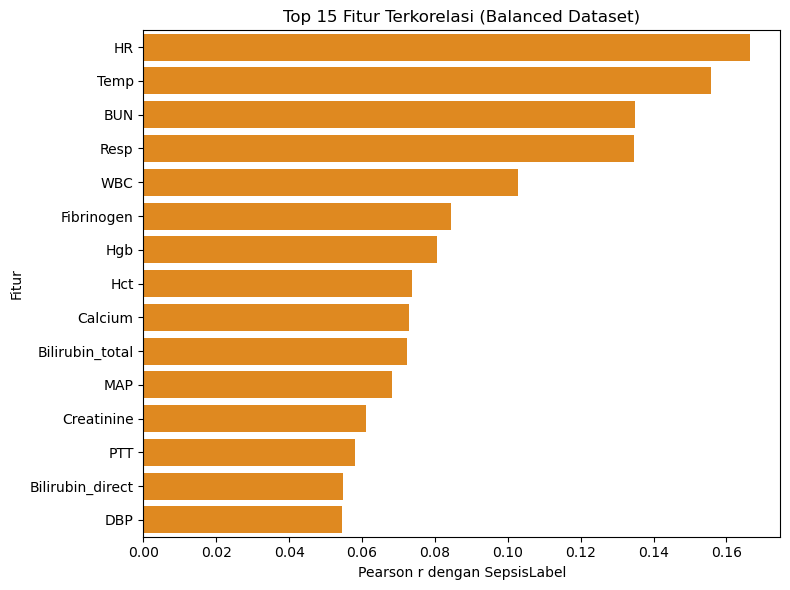

In [9]:
admin_cols = ["ICULOS", "Hour", "HospAdmTime", "Patient_ID"]
df_eda = df_balanced.drop(columns=admin_cols)

num_b = df_eda.select_dtypes(include=[np.number])
corr_b = num_b.corr(method="pearson")["SepsisLabel"].drop("SepsisLabel").abs()
top15_b = corr_b.sort_values(ascending=False).head(15)

print("Top 15 Pearson r vs SepsisLabel (Balanced Dataset):")
print(top15_b.round(4).to_string())

plt.figure(figsize=(8, 6))
sns.barplot(x=top15_b.values, y=top15_b.index, orient="h", color="darkorange")
plt.xlabel("Pearson r dengan SepsisLabel")
plt.ylabel("Fitur")
plt.title("Top 15 Fitur Terkorelasi (Balanced Dataset)")
plt.tight_layout()
plt.savefig("../reports/eda_balanced_correlation.png", dpi=150)
plt.show()

In [10]:
missing_pct_balanced = (df_balanced.isna().mean() * 100).sort_values(ascending=False)
missing_table_balanced = missing_pct_balanced.to_frame("missing_pct").round(2)
print("Missing % per kolom setelah imputasi (balanced dataset):")
print(missing_table_balanced.to_string())

focus = ["Lactate", "O2Sat", "pH", "PaCO2", "SaO2", "Resp"]
print("\nFocus clinical markers (missing %):")
print(missing_pct_balanced.loc[focus].round(2).to_string())

Missing % per kolom setelah imputasi (balanced dataset):
                  missing_pct
Hour                      0.0
WBC                       0.0
Magnesium                 0.0
Phosphate                 0.0
Potassium                 0.0
Bilirubin_total           0.0
TroponinI                 0.0
Hct                       0.0
Hgb                       0.0
PTT                       0.0
Fibrinogen                0.0
Glucose                   0.0
Platelets                 0.0
Age                       0.0
Gender                    0.0
Unit1                     0.0
Unit2                     0.0
HospAdmTime               0.0
ICULOS                    0.0
SepsisLabel               0.0
Lactate                   0.0
Bilirubin_direct          0.0
HR                        0.0
HCO3                      0.0
O2Sat                     0.0
Temp                      0.0
SBP                       0.0
MAP                       0.0
DBP                       0.0
Resp                      0.0
EtCO2        

### Temuan EDA

1. Marker biologis utama seperti Lactate, O2Sat, pH, PaCO2, dan SaO2 memiliki tingkat missing yang sangat tinggi pada data mentah (93-97%). Hal ini menjustifikasi strategi imputasi per-pasien dengan ffill dan median global yang diterapkan di EDA bagian 2.
2. Kolom administratif seperti ICULOS dan HospAdmTime muncul di antara fitur terkorelasi tertinggi dengan SepsisLabel pada EDA awal. Ini merupakan kebocoran temporal (administrative leakage) yang harus dibuang sebelum training agar model tidak belajar dari shortcut non-biologis.
3. Ketidakseimbangan kelas yang ekstrem (rasio 54.6:1) menjustifikasi downsampling kelas mayoritas pada EDA bagian 2. Setelah balancing menjadi 1:2, ranking korelasi mencerminkan sinyal biologis yang lebih murni.

In [14]:
df_balanced.to_csv("../data/df_balanced.csv", index=False)
print(f"Berhasil disimpan pada ../data/df_balanced.csv\nshape: {df_balanced.shape}")

Berhasil disimpan pada ../data/df_balanced.csv
shape: (83748, 43)
